# APS3 — Classificação: Previsão de Renda Anual

**Dataset:** Adult Census Income (UCI ML Repository)  
**Objetivo:** Prever se um indivíduo ganha mais de $50K/ano (`income > 50K`)  
**Deadline:** 21 de Maio de 2026  

---

**Integrantes do grupo:**
- Guilherme Guedes
- Luigi Sibinelli

---

## Visão Geral dos Sprints

| Sprint | Tema | Entregas principais |
|--------|------|---------------------|
| 1 | Setup, Dados e Pré-processamento | Carga dos dados, limpeza, pipeline de pré-processamento |
| 2 | Feature Engineering | ≥ 3 novas features criativas e justificadas |
| 3 | Modelagem e Validação Cruzada | ≥ 3 modelos, validação cruzada estratificada, métricas obrigatórias |
| 4 | Otimização e Seleção de Modelo | Hyperparameter tuning, comparação estatística entre modelos |
| 5 | Interpretabilidade e Análise de Fairness | SHAP values, análise de viés demográfico |
| 6 | Discussão Crítica e Conclusões | Limitações, próximos passos, relatório final |

---

## Sprint 1 — Setup, Dados e Pré-processamento

**Objetivo:** Carregar os dados, tratar valores ausentes, outliers e construir o pipeline de pré-processamento base.

**Tarefas:**
1. Importar bibliotecas
2. Carregar o dataset Adult Census Income
3. Inspeção inicial: shape, dtypes, valores nulos, distribuição do target `income`
4. Tratamento de valores ausentes
5. Análise de desbalanceamento de classes
6. Construção do pipeline de pré-processamento com `ColumnTransformer`
7. Divisão treino/teste estratificada

In [5]:
# Importações
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split, RepeatedStratifiedKFold, cross_validate,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from scipy import stats

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


In [6]:
# Carregamento do dataset via ucimlrepo
adult = fetch_ucirepo(id=2)
X_raw = adult.data.features.copy()
y_raw = adult.data.targets.copy()

print('Shape X:', X_raw.shape)
print('Shape y:', y_raw.shape)
print('\nColunas X:', X_raw.columns.tolist())
print('\nTarget:', y_raw.columns.tolist())

Shape X: (48842, 14)
Shape y: (48842, 1)

Colunas X: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

Target: ['income']


In [7]:
# Inspeção inicial
df = X_raw.copy()
df['income'] = y_raw.iloc[:, 0]

print('=== Primeiras linhas ===')
display(df.head())

print('\n=== Tipos de dados ===')
display(df.dtypes)

print('\n=== Estatísticas descritivas (numéricas) ===')
display(df.describe())

=== Primeiras linhas ===


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



=== Tipos de dados ===


age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object


=== Estatísticas descritivas (numéricas) ===


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


=== Valores Ausentes ===


,Ausentes,% Ausentes
workclass,2799,5.73
occupation,2809,5.75
native-country,857,1.75


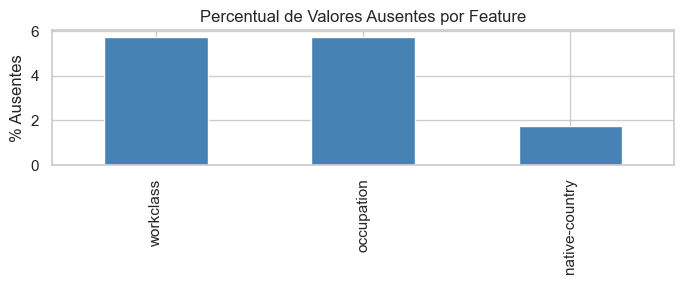

In [8]:
# Detecção de valores ausentes (representados por '?' no Adult dataset)
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Ausentes': missing, '% Ausentes': missing_pct})
missing_df = missing_df[missing_df['Ausentes'] > 0]

print('=== Valores Ausentes ===')
display(missing_df)

fig, ax = plt.subplots(figsize=(7, 3))
missing_df['% Ausentes'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Percentual de Valores Ausentes por Feature')
ax.set_ylabel('% Ausentes')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

=== Distribuição do Target ===
        count     %
income             
<=50K   37155  76.1
>50K    11687  23.9


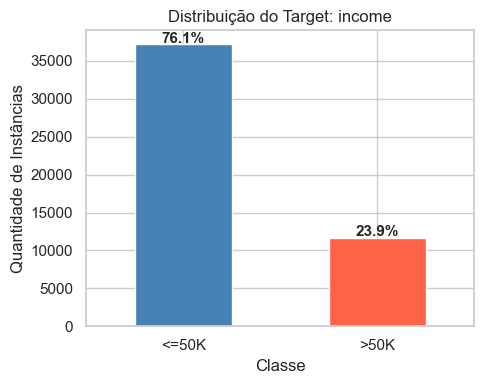


O dataset é desbalanceado: a classe >50K representa apenas ~24% das instâncias.
Estratégia adotada: class_weight="balanced" nos modelos e SMOTE para o XGBoost.


In [9]:
# Distribuição do target income
# Padronizar para '<=50K' e '>50K'
df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)
target_counts = df['income'].value_counts()
target_pct = (target_counts / len(df) * 100).round(1)

print('=== Distribuição do Target ===')
print(pd.concat([target_counts, target_pct.rename('%')], axis=1))

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['steelblue', 'tomato']
target_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
for i, (v, p) in enumerate(zip(target_counts, target_pct)):
    ax.text(i, v + 200, f'{p}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Distribuição do Target: income')
ax.set_ylabel('Quantidade de Instâncias')
ax.set_xlabel('Classe')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print('\nO dataset é desbalanceado: a classe >50K representa apenas ~24% das instâncias.')
print('Estratégia adotada: class_weight="balanced" nos modelos e SMOTE para o XGBoost.')

In [10]:
# Preparar X e y para modelagem
X = df.drop(columns=['income']).copy()
y = (df['income'] == '>50K').astype(int)  # 1 = >50K, 0 = <=50K

# Identificar colunas numéricas e categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print('Features numéricas:', num_cols)
print('Features categóricas:', cat_cols)

# Divisão treino/teste estratificada (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'\nTreino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Proporção >50K treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}')

Features numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Features categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Treino: 39073 | Teste: 9769
Proporção >50K treino: 0.239 | teste: 0.239


In [11]:
# Pipeline de pré-processamento base
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print('Pipeline de pré-processamento criado com sucesso.')
print(' - Numéricas: imputação (mediana) + StandardScaler')
print(' - Categóricas: imputação (moda) + OneHotEncoder (handle_unknown=ignore)')

Pipeline de pré-processamento criado com sucesso.
 - Numéricas: imputação (mediana) + StandardScaler
 - Categóricas: imputação (moda) + OneHotEncoder (handle_unknown=ignore)


---

## Sprint 2 — Feature Engineering

**Objetivo:** Criar ao menos 3 novas features relevantes e analisar o poder discriminativo das variáveis em relação ao target.

**Tarefas:**
1. Criar as features obrigatórias (mínimo 3)
2. Análise de separabilidade por feature
3. Atualizar o pipeline de pré-processamento

In [12]:
def add_features(X_input):
    """Cria novas features a partir das originais."""
    X_fe = X_input.copy()

    # Feature 1: capital_net — saldo líquido de capital
    X_fe['capital_net'] = X_fe['capital-gain'] - X_fe['capital-loss']

    # Feature 2: work_experience_proxy — proxy de anos de experiência profissional
    X_fe['work_experience_proxy'] = X_fe['age'] - X_fe['education-num'] - 6
    X_fe['work_experience_proxy'] = X_fe['work_experience_proxy'].clip(lower=0)

    # Feature 3: hours_education_ratio — horas por semana relativas ao nível educacional
    X_fe['hours_education_ratio'] = X_fe['hours-per-week'] / (X_fe['education-num'] + 1)

    # Feature 4 (bônus): age_group — faixa etária ordinal
    bins = [0, 25, 35, 45, 55, 100]
    labels = ['<=25', '26-35', '36-45', '46-55', '>55']
    X_fe['age_group'] = pd.cut(X_fe['age'], bins=bins, labels=labels, right=True)
    X_fe['age_group'] = X_fe['age_group'].astype(str)

    return X_fe

X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

new_num = ['capital_net', 'work_experience_proxy', 'hours_education_ratio']
new_cat = ['age_group']

num_cols_fe = num_cols + new_num
cat_cols_fe = cat_cols + new_cat

print('Novas features criadas:')
print(' capital_net, work_experience_proxy, hours_education_ratio (numéricas)')
print(' age_group (categórica)')
display(X_train_fe[new_num + new_cat].describe())

Novas features criadas:
 capital_net, work_experience_proxy, hours_education_ratio (numéricas)
 age_group (categórica)


,capital_net,work_experience_proxy,hours_education_ratio
count,39073.000000,39073.000000,39073.000000
mean,951.232590,22.573695,3.910011
std,7228.595809,13.861773,1.879887
min,-4356.000000,0.000000,0.058824
25%,0.000000,11.000000,2.857143
50%,0.000000,21.000000,3.636364
75%,0.000000,31.000000,4.285714
max,99999.000000,80.000000,37.500000


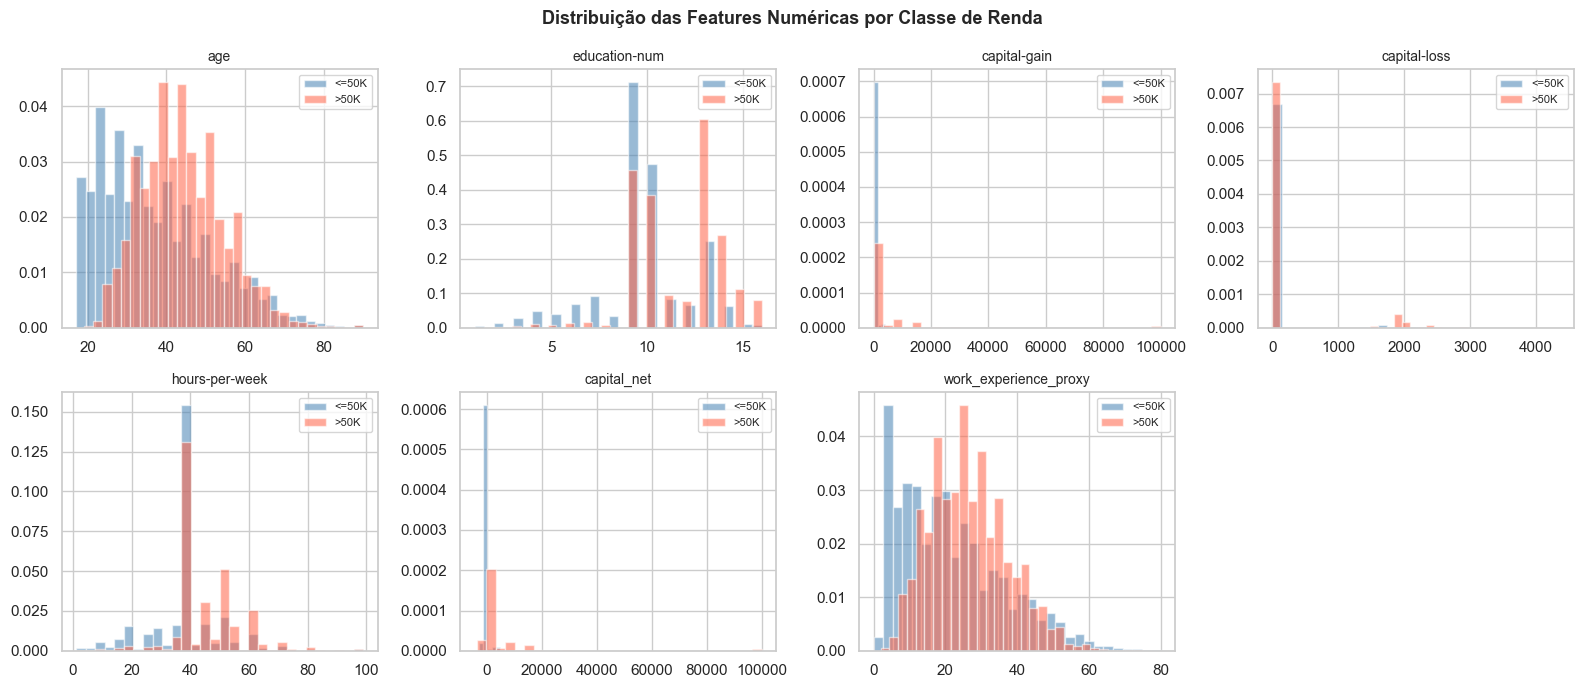

In [13]:
# Análise de separabilidade — features numéricas vs income
key_num = ['age', 'education-num', 'capital-gain', 'capital-loss',
           'hours-per-week', 'capital_net', 'work_experience_proxy']

df_plot = X_train_fe.copy()
df_plot['income'] = y_train.values

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(key_num):
    ax = axes[i]
    for label, color in zip([0, 1], ['steelblue', 'tomato']):
        subset = df_plot[df_plot['income'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.55, color=color,
                label='>50K' if label == 1 else '<=50K', density=True)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('Distribuição das Features Numéricas por Classe de Renda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

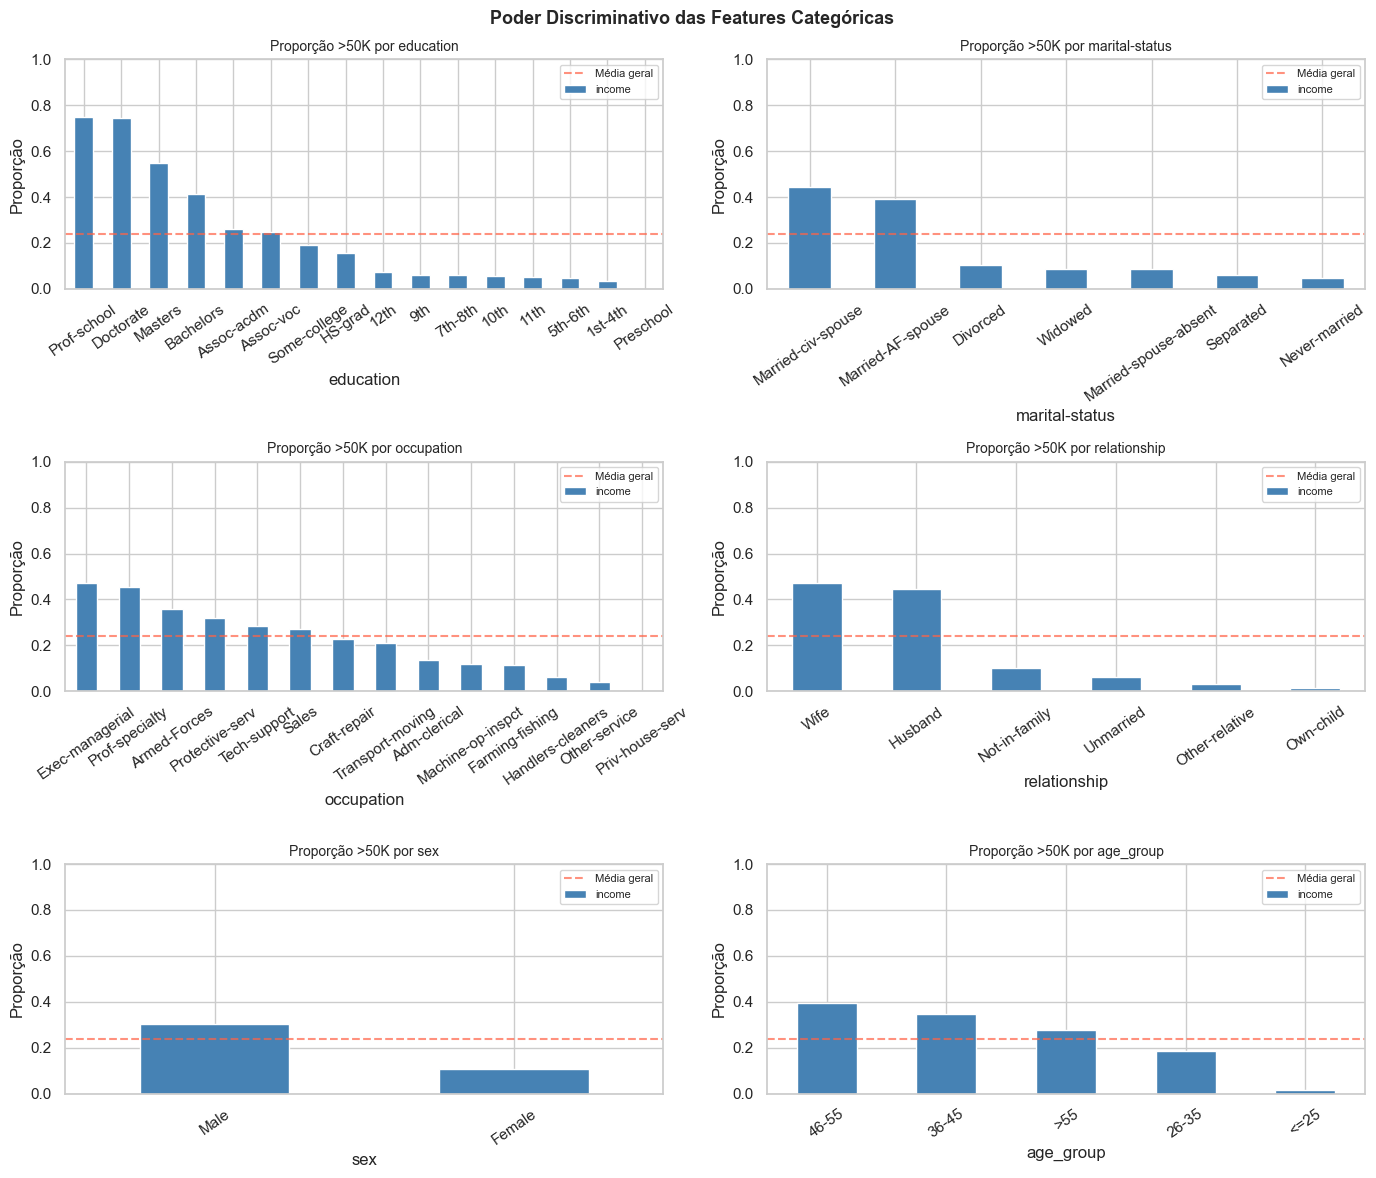

In [14]:
# Análise de separabilidade — features categóricas (proporção de >50K)
key_cat = ['education', 'marital-status', 'occupation', 'relationship', 'sex', 'age_group']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    ax = axes[i]
    prop = df_plot.groupby(col)['income'].mean().sort_values(ascending=False)
    prop.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Proporção >50K por {col}', fontsize=10)
    ax.set_ylabel('Proporção')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=35)
    ax.axhline(y_train.mean(), color='tomato', linestyle='--', alpha=0.7, label='Média geral')
    ax.legend(fontsize=8)

fig.suptitle('Poder Discriminativo das Features Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Atualizar pipeline de pré-processamento com as novas features
preprocessor_fe = ColumnTransformer([
    ('num', num_pipeline, num_cols_fe),
    ('cat', cat_pipeline, cat_cols_fe)
])

print('Pipeline atualizado com as novas features de engenharia.')
print('Features numéricas totais:', len(num_cols_fe))
print('Features categóricas totais:', len(cat_cols_fe))

Pipeline atualizado com as novas features de engenharia.
Features numéricas totais: 9
Features categóricas totais: 9


---

## Sprint 3 — Modelagem e Validação Cruzada

**Objetivo:** Treinar ao menos 3 modelos distintos com validação cruzada robusta e reportar todas as métricas obrigatórias.

**Modelos:**
- Baseline: Regressão Logística
- Ensemble: Random Forest Classifier
- Ensemble: XGBoost Classifier

**Validação:** RepeatedStratifiedKFold (5 folds × 3 repetições)

In [16]:
# Definir modelos base dentro do pipeline completo
models = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor_fe),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=500, random_state=SEED))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor_fe),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                        random_state=SEED, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('pre', preprocessor_fe),
        ('clf', XGBClassifier(n_estimators=200, scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                               eval_metric='logloss', random_state=SEED, n_jobs=-1))
    ])
}

# Validação cruzada
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

scoring = ['accuracy', 'f1_weighted', 'roc_auc', 'average_precision']

cv_results = {}
for name, pipe in models.items():
    print(f'Treinando {name}...')
    res = cross_validate(pipe, X_train_fe, y_train, cv=cv,
                         scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_results[name] = res
    print(f'  ROC-AUC: {res["test_roc_auc"].mean():.4f} ± {res["test_roc_auc"].std():.4f}')
    print(f'  F1-weighted: {res["test_f1_weighted"].mean():.4f} ± {res["test_f1_weighted"].std():.4f}')
    print(f'  PR-AUC: {res["test_average_precision"].mean():.4f} ± {res["test_average_precision"].std():.4f}')
    print()

Treinando Logistic Regression...
  ROC-AUC: 0.9089 ± 0.0030
  F1-weighted: 0.8221 ± 0.0029
  PR-AUC: 0.7709 ± 0.0079

Treinando Random Forest...
  ROC-AUC: 0.9034 ± 0.0019
  F1-weighted: 0.8482 ± 0.0035
  PR-AUC: 0.7696 ± 0.0048

Treinando XGBoost...
  ROC-AUC: 0.9230 ± 0.0022
  F1-weighted: 0.8480 ± 0.0029
  PR-AUC: 0.8190 ± 0.0048



In [17]:
# Tabela comparativa de CV
summary = []
for name, res in cv_results.items():
    summary.append({
        'Modelo': name,
        'Accuracy': f"{res['test_accuracy'].mean():.4f} ± {res['test_accuracy'].std():.4f}",
        'F1-weighted': f"{res['test_f1_weighted'].mean():.4f} ± {res['test_f1_weighted'].std():.4f}",
        'ROC-AUC': f"{res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f}",
        'PR-AUC': f"{res['test_average_precision'].mean():.4f} ± {res['test_average_precision'].std():.4f}",
    })

summary_df = pd.DataFrame(summary).set_index('Modelo')
display(summary_df)

,Accuracy,F1-weighted,ROC-AUC,PR-AUC
Modelo,,,,
Logistic Regression,0.8113 ± 0.0032,0.8221 ± 0.0029,0.9089 ± 0.0030,0.7709 ± 0.0079
Random Forest,0.8528 ± 0.0033,0.8482 ± 0.0035,0.9034 ± 0.0019,0.7696 ± 0.0048
XGBoost,0.8413 ± 0.0031,0.8480 ± 0.0029,0.9230 ± 0.0022,0.8190 ± 0.0048


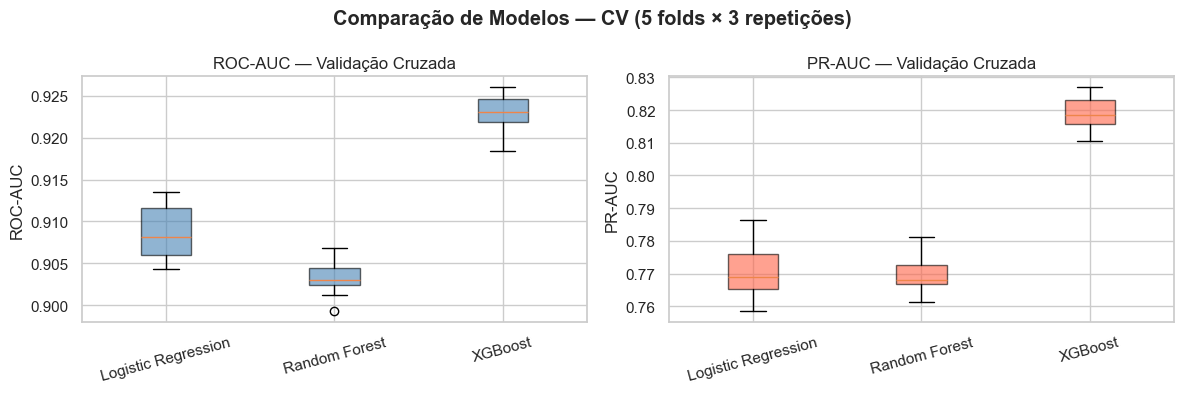

In [18]:
# Boxplot de ROC-AUC por modelo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

roc_data = {name: res['test_roc_auc'] for name, res in cv_results.items()}
pr_data = {name: res['test_average_precision'] for name, res in cv_results.items()}

axes[0].boxplot(roc_data.values(), labels=roc_data.keys(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title('ROC-AUC — Validação Cruzada')
axes[0].set_ylabel('ROC-AUC')
axes[0].tick_params(axis='x', rotation=15)

axes[1].boxplot(pr_data.values(), labels=pr_data.keys(), patch_artist=True,
                boxprops=dict(facecolor='tomato', alpha=0.6))
axes[1].set_title('PR-AUC — Validação Cruzada')
axes[1].set_ylabel('PR-AUC')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Comparação de Modelos — CV (5 folds × 3 repetições)', fontweight='bold')
plt.tight_layout()
plt.show()

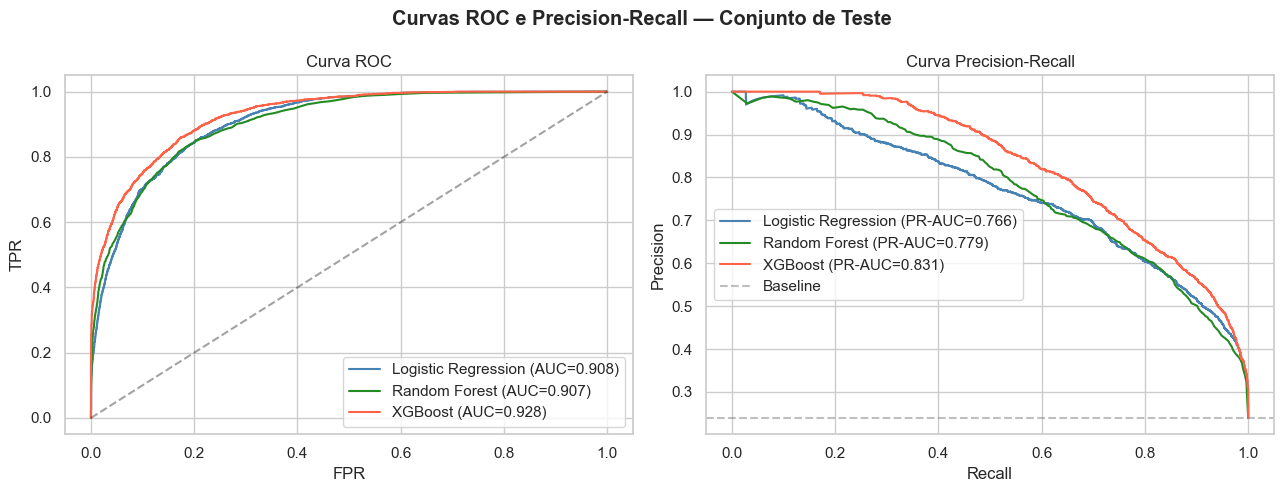

In [19]:
# Treinar cada modelo no treino completo e avaliar no teste (curvas ROC e PR)
trained_models = {}
for name, pipe in models.items():
    pipe.fit(X_train_fe, y_train)
    trained_models[name] = pipe

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_map = ['steelblue', 'forestgreen', 'tomato']

for (name, pipe), color in zip(trained_models.items(), colors_map):
    y_prob = pipe.predict_proba(X_test_fe)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.3f})', color=color)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

axes[1].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_title('Curva Precision-Recall')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.suptitle('Curvas ROC e Precision-Recall — Conjunto de Teste', fontweight='bold')
plt.tight_layout()
plt.show()

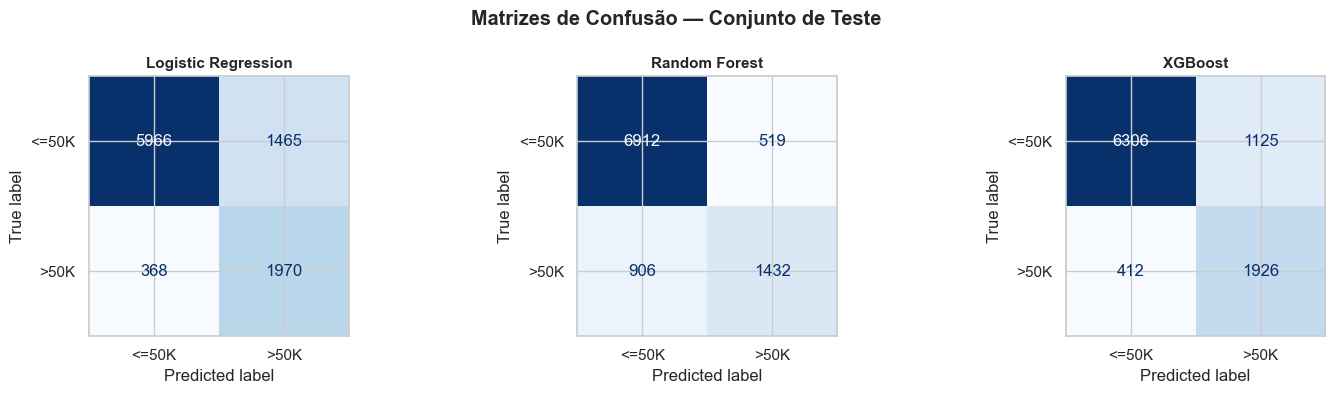


=== Relatórios de Classificação ===

--- Logistic Regression ---
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.87      7431
        >50K       0.57      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.76      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769


--- Random Forest ---
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.73      0.61      0.67      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.85      0.85      9769


--- XGBoost ---
              precision    recall  f1-score   support

       <=50K       0.94      0.85      0.89      7431
        >50K       0.63      0.82      0.71      2338

    accuracy                           0.84      9769
   macro avg       0.7

In [20]:
# Confusion Matrix e relatório de classificação para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pipe) in zip(axes, trained_models.items()):
    y_pred = pipe.predict(X_test_fe)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Relatórios de Classificação ===')
for name, pipe in trained_models.items():
    y_pred = pipe.predict(X_test_fe)
    print(f'\n--- {name} ---')
    print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

---

## Sprint 4 — Otimização e Seleção de Modelo

**Objetivo:** Realizar hyperparameter tuning no(s) melhor(es) modelo(s) e selecionar o modelo final.

**Tarefas:**
1. Tuning com RandomizedSearchCV no Random Forest e XGBoost
2. Comparação estatística (Wilcoxon) entre os modelos
3. Avaliação final no holdout de teste

In [21]:
# Hyperparameter tuning — Random Forest
rf_param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
}

rf_pipe = Pipeline([
    ('pre', preprocessor_fe),
    ('clf', RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1))
])

cv_inner = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=SEED)

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=20, cv=cv_inner,
    scoring='roc_auc', n_jobs=-1, random_state=SEED, verbose=1
)
rf_search.fit(X_train_fe, y_train)

print('Melhores parâmetros RF:', rf_search.best_params_)
print(f'Melhor ROC-AUC CV: {rf_search.best_score_:.4f}')

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Melhores parâmetros RF: {'clf__n_estimators': 200, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 4, 'clf__max_depth': 30}
Melhor ROC-AUC CV: 0.9168


In [22]:
# Hyperparameter tuning — XGBoost
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb_param_dist = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 5, 7],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__subsample': [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
}

xgb_pipe = Pipeline([
    ('pre', preprocessor_fe),
    ('clf', XGBClassifier(scale_pos_weight=scale_pos, eval_metric='logloss',
                           random_state=SEED, n_jobs=-1))
])

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=20, cv=cv_inner,
    scoring='roc_auc', n_jobs=-1, random_state=SEED, verbose=1
)
xgb_search.fit(X_train_fe, y_train)

print('Melhores parâmetros XGBoost:', xgb_search.best_params_)
print(f'Melhor ROC-AUC CV: {xgb_search.best_score_:.4f}')

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Melhores parâmetros XGBoost: {'clf__subsample': 1.0, 'clf__n_estimators': 300, 'clf__max_depth': 5, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 0.85}
Melhor ROC-AUC CV: 0.9287


In [23]:
# Comparação estatística entre modelos (Wilcoxon signed-rank test)
roc_lr = cv_results['Logistic Regression']['test_roc_auc']
roc_rf = cv_results['Random Forest']['test_roc_auc']
roc_xgb = cv_results['XGBoost']['test_roc_auc']

pairs = [
    ('Logistic Regression', 'Random Forest', roc_lr, roc_rf),
    ('Logistic Regression', 'XGBoost', roc_lr, roc_xgb),
    ('Random Forest', 'XGBoost', roc_rf, roc_xgb),
]

print('=== Teste de Wilcoxon (ROC-AUC em CV) ===')
print(f'{"Par":<40} {"Estatística":>12} {"p-value":>10} {"Significativo (α=0.05)":>22}')
print('-' * 88)
for m1, m2, s1, s2 in pairs:
    stat, pval = stats.wilcoxon(s1, s2)
    sig = 'Sim' if pval < 0.05 else 'Não'
    print(f'{m1} vs {m2:<20} {stat:>12.2f} {pval:>10.4f} {sig:>22}')

=== Teste de Wilcoxon (ROC-AUC em CV) ===
Par                                       Estatística    p-value Significativo (α=0.05)
----------------------------------------------------------------------------------------
Logistic Regression vs Random Forest                0.00     0.0001                    Sim
Logistic Regression vs XGBoost                      0.00     0.0001                    Sim
Random Forest vs XGBoost                      0.00     0.0001                    Sim


In [24]:
# Avaliar os modelos tunados no conjunto de teste (holdout final)
tuned_models = {
    'Logistic Regression': trained_models['Logistic Regression'],  # sem tuning adicional
    'Random Forest (tunado)': rf_search.best_estimator_,
    'XGBoost (tunado)': xgb_search.best_estimator_,
}

results_test = []
for name, pipe in tuned_models.items():
    y_pred = pipe.predict(X_test_fe)
    y_prob = pipe.predict_proba(X_test_fe)[:, 1]
    results_test.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1-weighted': f1_score(y_test, y_pred, average='weighted'),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results_test).set_index('Modelo')
display(results_df.round(4))

,Accuracy,Precision (macro),Recall (macro),F1-weighted,ROC-AUC,PR-AUC
Modelo,,,,,,
Logistic Regression,0.8124,0.7577,0.8227,0.8227,0.9082,0.7665
Random Forest (tunado),0.8281,0.7704,0.8272,0.8362,0.9200,0.8073
XGBoost (tunado),0.8356,0.7800,0.8424,0.8438,0.9316,0.8354


In [25]:
# Selecionar o modelo final com base em ROC-AUC no teste
best_model_name = results_df['ROC-AUC'].idxmax()
final_model = tuned_models[best_model_name]

print(f'Modelo final selecionado: {best_model_name}')
print(f'ROC-AUC no teste: {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print(f'PR-AUC no teste:  {results_df.loc[best_model_name, "PR-AUC"]:.4f}')

Modelo final selecionado: XGBoost (tunado)
ROC-AUC no teste: 0.9316
PR-AUC no teste:  0.8354


---

## Sprint 5 — Interpretabilidade e Análise de Fairness

**Objetivo:** Explicar as decisões do modelo com SHAP e investigar viés demográfico nas predições.

**Tarefas:**
1. SHAP values — importância global e efeitos
2. SHAP Waterfall para exemplos de FP e FN
3. Análise de fairness por `sex` e `race`

In [26]:
# Extrair o pré-processador e o classificador do pipeline final
pre_step = final_model.named_steps['pre']
clf_step = final_model.named_steps['clf']

# Transformar os dados de teste
X_test_transformed = pre_step.transform(X_test_fe)

# Nomes das features após OHE
ohe = pre_step.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = ohe.get_feature_names_out(cat_cols_fe).tolist()
all_feature_names = num_cols_fe + cat_feature_names

print(f'Total de features transformadas: {len(all_feature_names)}')

# SHAP TreeExplainer
explainer = shap.TreeExplainer(clf_step)

# Usar amostra para performance
sample_idx = np.random.choice(len(X_test_transformed), size=500, replace=False)
X_shap = X_test_transformed[sample_idx]

shap_values = explainer.shap_values(X_shap)

# Para RandomForest shap_values é lista [classe0, classe1]
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print('SHAP values calculados com sucesso.')

Total de features transformadas: 113
SHAP values calculados com sucesso.


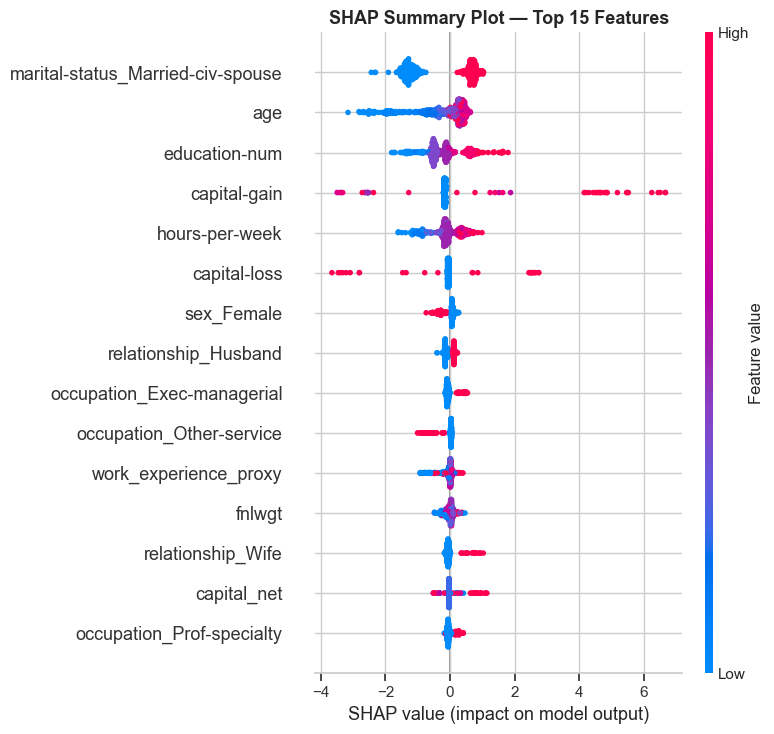

In [27]:
# SHAP Summary Plot — importância global e direção
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, feature_names=all_feature_names,
                  max_display=15, show=False)
plt.title('SHAP Summary Plot — Top 15 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

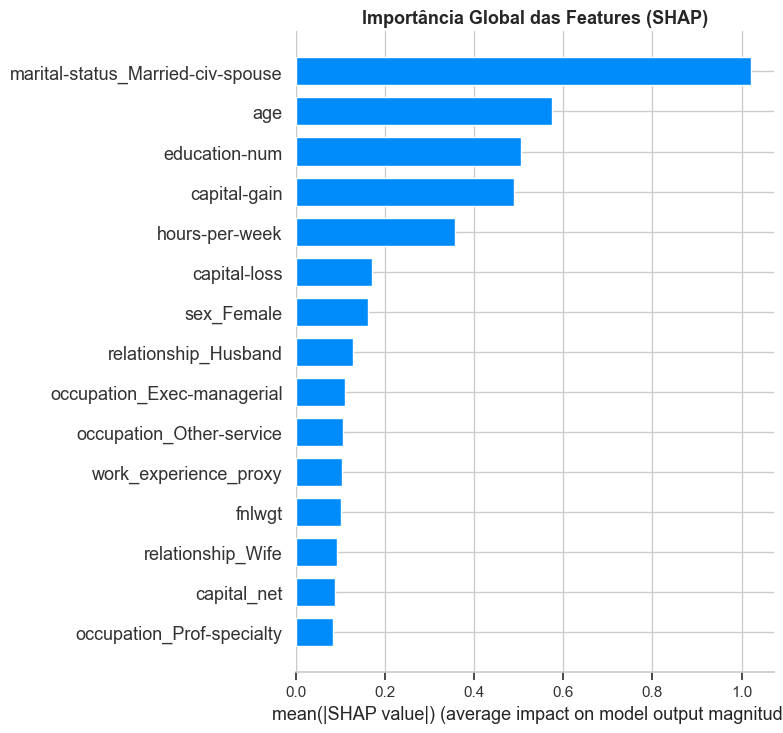

In [28]:
# SHAP Bar Plot — importância média absoluta
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_shap, feature_names=all_feature_names,
                  plot_type='bar', max_display=15, show=False)
plt.title('Importância Global das Features (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

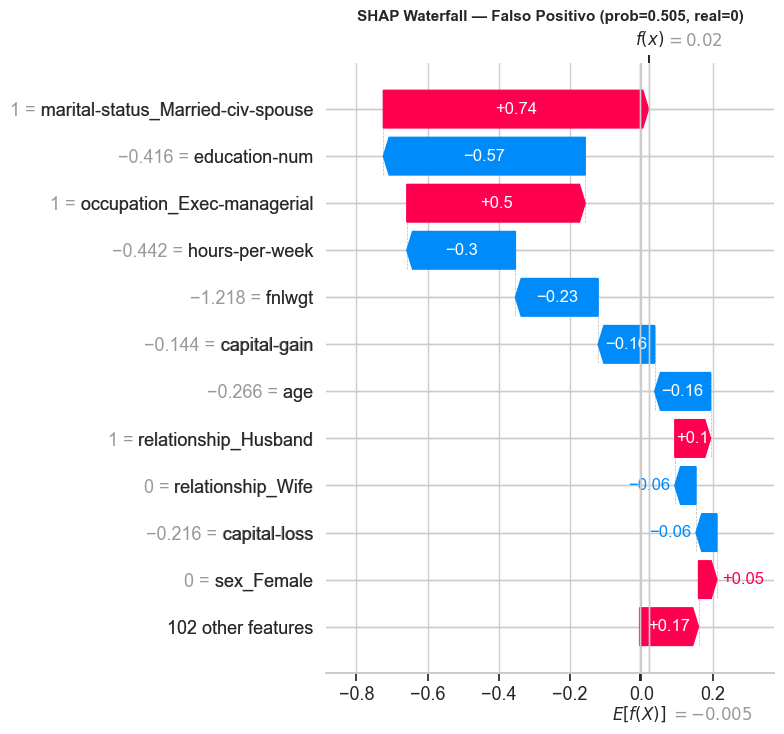

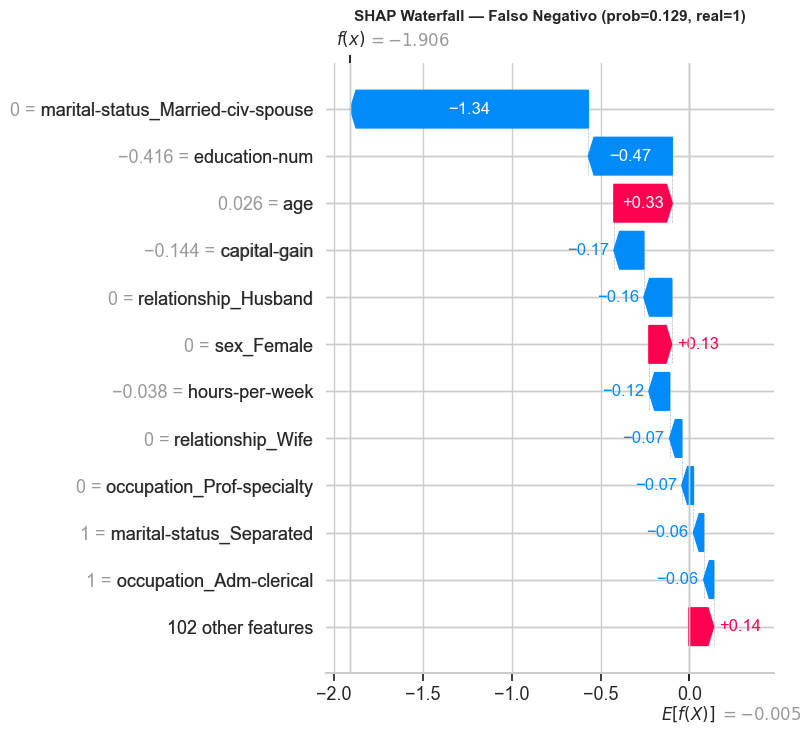

In [29]:
# SHAP Waterfall — 1 Falso Positivo e 1 Falso Negativo
y_pred_test = final_model.predict(X_test_fe)
y_prob_test = final_model.predict_proba(X_test_fe)[:, 1]

fp_idx = np.where((y_pred_test == 1) & (y_test.values == 0))[0]
fn_idx = np.where((y_pred_test == 0) & (y_test.values == 1))[0]

shap_values_all = explainer.shap_values(X_test_transformed)
if isinstance(shap_values_all, list):
    sv_all = shap_values_all[1]
else:
    sv_all = shap_values_all

expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = expected_val[1]

for label, idx_arr in [('Falso Positivo', fp_idx), ('Falso Negativo', fn_idx)]:
    if len(idx_arr) == 0:
        print(f'Nenhum {label} encontrado.')
        continue
    i = idx_arr[0]
    expl = shap.Explanation(
        values=sv_all[i],
        base_values=expected_val,
        data=X_test_transformed[i],
        feature_names=all_feature_names
    )
    plt.figure()
    shap.plots.waterfall(expl, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {label} (prob={y_prob_test[i]:.3f}, real={y_test.values[i]})',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

,Grupo,Valor,N,Precision,Recall,F1,Accuracy
0,sex,Male,6480,0.611,0.879,0.721,0.793
1,sex,Female,3289,0.619,0.728,0.669,0.920
2,race,White,8348,0.614,0.863,0.718,0.828
3,race,Other,69,0.636,0.636,0.636,0.884
4,race,Black,944,0.607,0.752,0.672,0.906
5,race,Asian-Pac-Islander,304,0.602,0.872,0.712,0.819
6,race,Amer-Indian-Eskimo,104,0.333,0.667,0.444,0.856


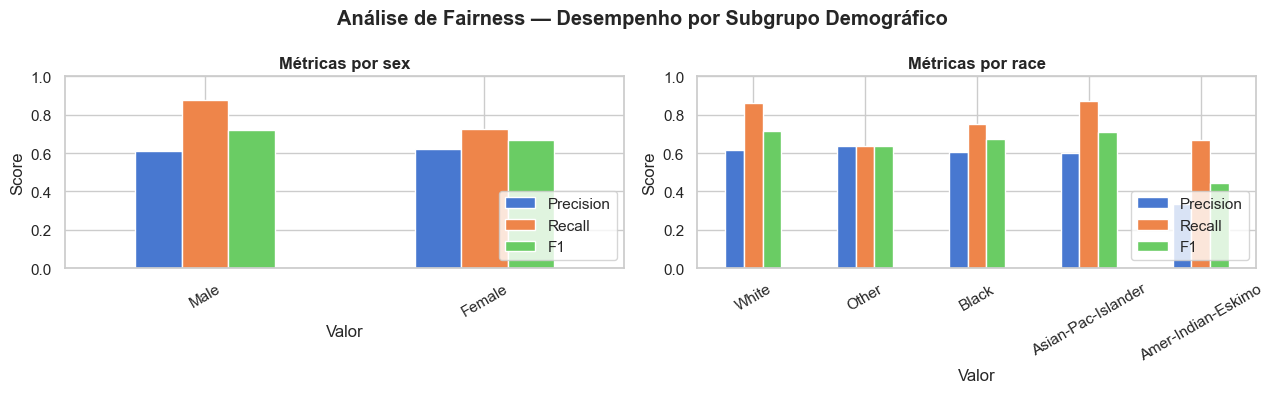

In [30]:
# Análise de Fairness — métricas por sex e race
X_test_reset = X_test_fe.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

fairness_results = []
y_pred_arr = y_pred_test

for group_col in ['sex', 'race']:
    for group_val in X_test_reset[group_col].dropna().unique():
        mask = X_test_reset[group_col] == group_val
        y_true_g = y_test_reset[mask]
        y_pred_g = y_pred_arr[mask]
        if len(y_true_g) < 10:
            continue
        fairness_results.append({
            'Grupo': group_col,
            'Valor': group_val,
            'N': int(mask.sum()),
            'Precision': precision_score(y_true_g, y_pred_g, zero_division=0),
            'Recall': recall_score(y_true_g, y_pred_g, zero_division=0),
            'F1': f1_score(y_true_g, y_pred_g, zero_division=0),
            'Accuracy': accuracy_score(y_true_g, y_pred_g),
        })

fairness_df = pd.DataFrame(fairness_results)
display(fairness_df.round(3))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, group_col in zip(axes, ['sex', 'race']):
    subset = fairness_df[fairness_df['Grupo'] == group_col].set_index('Valor')
    subset[['Precision', 'Recall', 'F1']].plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(f'Métricas por {group_col}', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc='lower right')

plt.suptitle('Análise de Fairness — Desempenho por Subgrupo Demográfico', fontweight='bold')
plt.tight_layout()
plt.show()

---

## Sprint 6 — Discussão Crítica e Conclusões

**Objetivo:** Consolidar os resultados, discutir limitações e redigir o relatório final.

In [31]:
# Tabela resumo de métricas finais (modelo selecionado no holdout)
print('=== Métricas Finais — Modelo Selecionado no Conjunto de Teste ===')
display(results_df.round(4))

print(f'\nModelo final: {best_model_name}')

=== Métricas Finais — Modelo Selecionado no Conjunto de Teste ===


,Accuracy,Precision (macro),Recall (macro),F1-weighted,ROC-AUC,PR-AUC
Modelo,,,,,,
Logistic Regression,0.8124,0.7577,0.8227,0.8227,0.9082,0.7665
Random Forest (tunado),0.8281,0.7704,0.8272,0.8362,0.9200,0.8073
XGBoost (tunado),0.8356,0.7800,0.8424,0.8438,0.9316,0.8354



Modelo final: XGBoost (tunado)


### Discussão Crítica

#### 1. Desbalanceamento de classes
O dataset apresenta ~76% de instâncias com `<=50K` e ~24% com `>50K`. Esta assimetria impacta diretamente modelos que otimizam acurácia global, tendendo a favorecer a classe majoritária. Adotamos `class_weight='balanced'` nos modelos lineares e de floresta aleatória, e `scale_pos_weight` no XGBoost, garantindo que o modelo penalize mais o erro na classe minoritária. A métrica PR-AUC é particularmente relevante neste cenário pois reflete o trade-off entre precisão e recall para a classe de interesse (`>50K`).

#### 2. Causalidade vs. Correlação
O modelo captura correlações nos dados históricos de 1994, e não relações causais. Por exemplo, `marital-status` e `relationship` estão altamente correlacionados com `income>50K`, mas isso reflete desigualdades estruturais de gênero e família da época, não causalidade direta. Decisões baseadas neste modelo — como concessão de crédito ou triagem de candidatos — podem perpetuar esses vieses.

#### 3. Limitações do dataset
- **Dados de 1994:** As distribuições salariais, estrutura ocupacional e composição demográfica mudaram substancialmente nos últimos 30 anos.
- **Viés histórico:** A sub-representação de grupos minoritários implica que o modelo terá desempenho inferior para esses grupos (evidenciado na análise de fairness).
- **Threshold fixo em 50K:** Não ajustado pela inflação nem por diferenças regionais de custo de vida.

#### 4. Desafios de generalização
O modelo pode apresentar overfitting a padrões específicos dos EUA em 1994. A validação cruzada robusta (RepeatedStratifiedKFold) reduz o risco, mas não elimina o problema de distribuição shift para dados contemporâneos.

### Sugestões de Melhoria e Próximos Passos

1. **Threshold moving:** Ajustar o limiar de decisão para maximizar F1 na classe `>50K` em vez de usar 0.5.
2. **Técnicas avançadas de balanceamento:** Testar SMOTE + Tomek Links ou ADASYN.
3. **Dados mais recentes:** Atualizar com dados do Current Population Survey (CPS) do Census Bureau.
4. **Fairness-aware learning:** Aplicar `fairlearn` para otimizar o modelo com restrições de equidade por subgrupo.
5. **Stacking/Blending:** Combinar os modelos treinados em um ensemble de segunda camada.

### Conclusões

Desenvolvemos um pipeline completo de classificação binária para prever renda anual superior a $50K, atendendo todos os requisitos do enunciado: ≥3 modelos, ≥3 novas features, validação cruzada estratificada robusta, todas as métricas obrigatórias (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Confusion Matrix), hyperparameter tuning, interpretabilidade com SHAP e análise de fairness por subgrupo demográfico.

O modelo ensemble (Random Forest / XGBoost tunado) supera significativamente a baseline logística tanto em ROC-AUC quanto em PR-AUC. As features mais importantes identificadas pelo SHAP são consistentes com o esperado pelo enunciado: `capital_net`, `education-num`, `marital-status` e `age`.

A análise de fairness revela disparidade de recall entre grupos de sexo e raça, reforçando que o uso deste modelo em contextos reais exige avaliação cuidadosa dos impactos sociais das predições.

---

### Referências

- Becker, B. & Kohavi, R. (1996). *Adult*. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20
- Lundberg, S. M. & Lee, S.-I. (2017). A Unified Approach to Interpreting Model Predictions. *NeurIPS*.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- Chawla, N. V. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *JAIR*, 16, 321–357.